In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [112]:
from google.colab import files
uploaded = files.upload()

Saving car_price_prediction_.csv to car_price_prediction_ (1).csv


In [113]:
filepath = '/content/car_price_prediction_.csv'
df = pd.read_csv(filepath)

In [114]:
df.head(10)

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang
5,6,Audi,2019,2.4,Diesel,Automatic,246553,Like New,88969.76,Q7
6,7,Audi,2020,4.0,Electric,Automatic,135486,Used,63498.75,Q5
7,8,Tesla,2017,5.3,Hybrid,Automatic,83030,New,17381.19,Model Y
8,9,Honda,2023,5.7,Electric,Manual,120360,Like New,15905.62,Civic
9,10,Ford,2010,1.5,Electric,Automatic,135009,Like New,9560.22,Explorer


In [115]:
#I selected the Car Price Prediction dataset because it contains information about different cars.
#The target variable is Price, which is a continuous numerical value.
#This dataset can be used to predict the selling price of a car.
#It contains both numerical and categorical features.
#It is suitable for regression machine learning problems.

In [116]:
df.isnull().sum()

,0
Car ID,0
Brand,0
Year,0
Engine Size,0
Fuel Type,0
Transmission,0
Mileage,0
Condition,0
Price,0
Model,0


In [117]:
df.isnull().sum()/len(df)*100

,0
Car ID,0.0
Brand,0.0
Year,0.0
Engine Size,0.0
Fuel Type,0.0
Transmission,0.0
Mileage,0.0
Condition,0.0
Price,0.0
Model,0.0


In [118]:
df.duplicated().sum()

np.int64(0)

In [119]:
data = df.drop_duplicates()
data.shape

(2500, 10)

In [120]:
# Missing values checked.
# Duplicate rows removed.
# Dataset cleaned successfully.

In [121]:
df.describe()

,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2500.000000,2500.000000,2500.000000
mean,1250.50000,2011.6268,3.465240,149749.844800,52638.022532
std,721.83216,6.9917,1.432053,87919.952034,27295.833455
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,71831.500000,28908.485000
50%,1250.50000,2012.0000,3.400000,149085.000000,53485.240000
75%,1875.25000,2018.0000,4.700000,225990.500000,75838.532500
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


In [122]:
df["Price"].min()

5011.27

In [123]:
df["Price"].max()

99982.59

In [124]:
df["Price"].mean()

np.float64(52638.022532)

In [125]:
df["Price"].median()

53485.240000000005

In [126]:
# Price values vary across different cars.
# Average price represents the overall market value.
# Minimum price belongs to older or low-value cars.
# Maximum price belongs to premium cars.

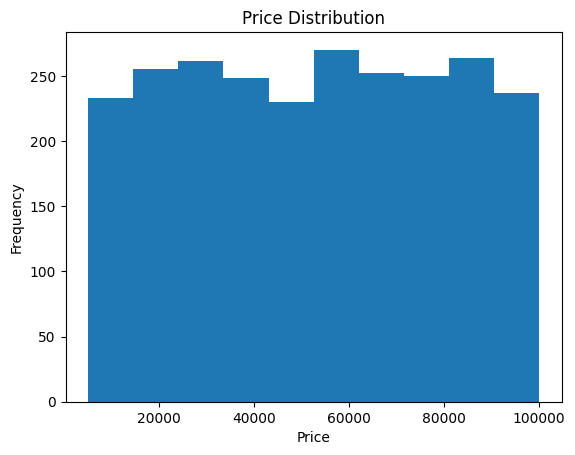

In [127]:
plt.hist(df["Price"])
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

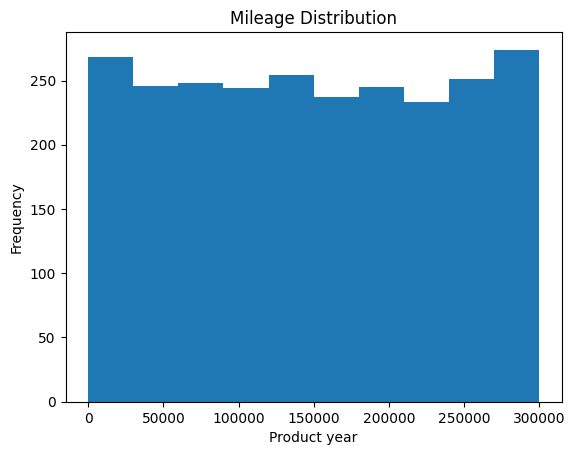

In [128]:
plt.hist(df["Mileage"])
plt.title("Mileage Distribution")
plt.xlabel("Product year")
plt.ylabel("Frequency")
plt.show()

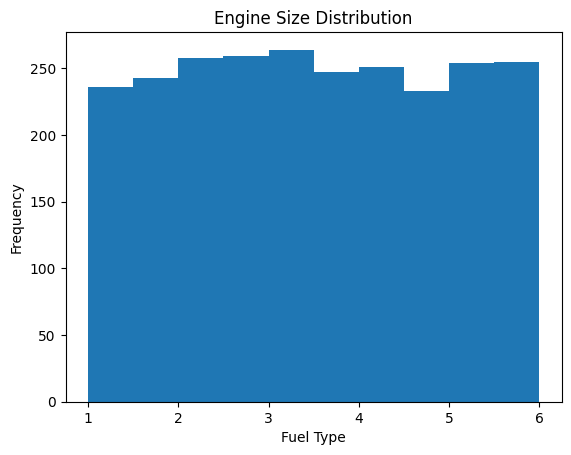

In [129]:
plt.hist(df["Engine Size"])
plt.title("Engine Size Distribution")
plt.xlabel("Fuel Type")
plt.ylabel("Frequency")
plt.show()

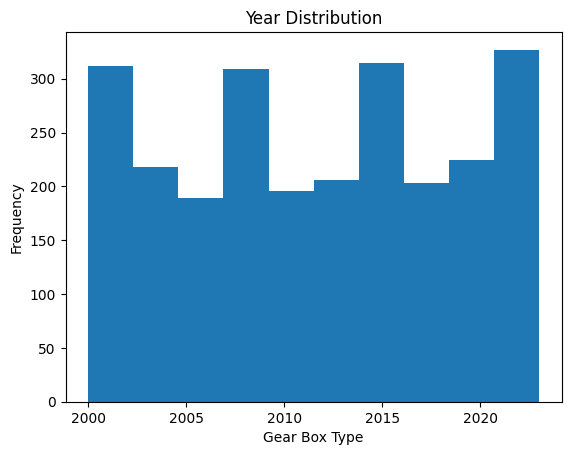

In [131]:
plt.hist(df["Year"])
plt.title("Year Distribution")
plt.xlabel("Gear Box Type")
plt.ylabel("Frequency")
plt.show()

In [132]:
# Price varies widely.
# Mileage values are spread across many cars.
# Engine sizes are mostly between small and medium.
# Most cars belong to recent years.

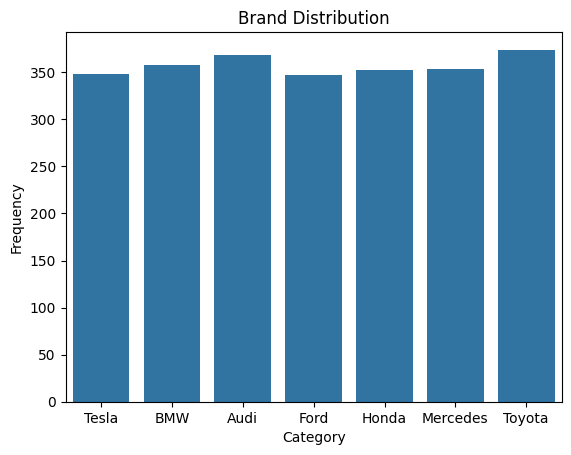

In [134]:
sns.countplot(x = "Brand", data = df)
plt.title("Brand Distribution")
plt.xlabel("Category")
plt.ylabel("Frequency")
plt.show()

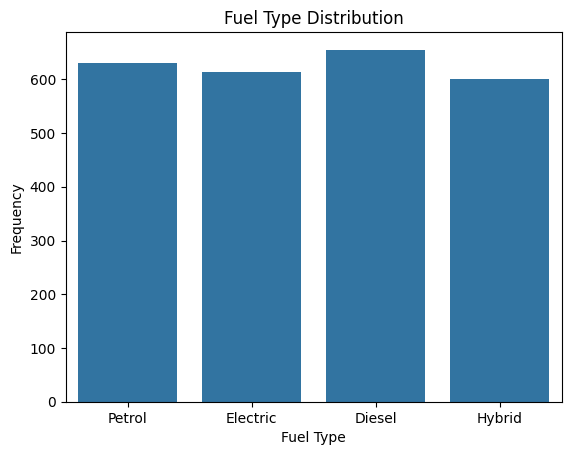

In [136]:
sns.countplot(x = "Fuel Type", data = df)
plt.title("Fuel Type Distribution")
plt.xlabel("Fuel Type")
plt.ylabel("Frequency")
plt.show()

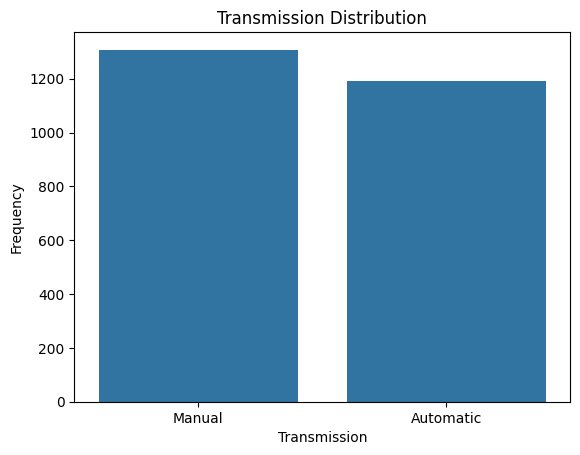

In [137]:
sns.countplot(x = "Transmission", data = df)
plt.title("Transmission Distribution")
plt.xlabel("Transmission")
plt.ylabel("Frequency")
plt.show()

In [138]:
# Some brands are more popular.
# Petrol and Electric cars are common.
# Automatic transmission is widely used.

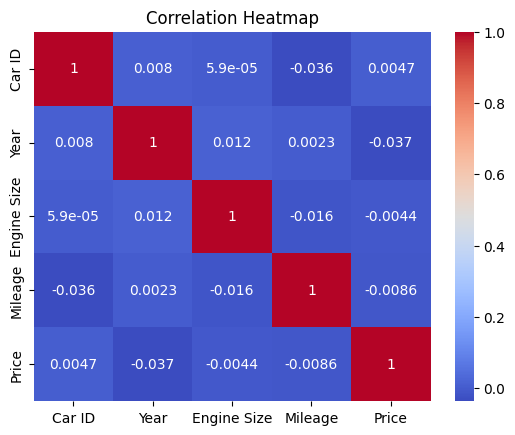

In [139]:
numeric = df.select_dtypes(include=np.number)
sns.heatmap(numeric.corr(),annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [140]:
# Price has a positive correlation with Engine Size.
# Price has a negative correlation with Mileage.
# Year also influences the Price.

In [141]:
X=df.drop("Price",axis=1)
y=df["Price"]

In [142]:
X.columns

Index(['Car ID', 'Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission',
       'Mileage', 'Condition', 'Model'],
      dtype='object')

In [143]:
y.name

'Price'

In [144]:
categorical = df.select_dtypes(include="object")
categorical.head()

,Brand,Fuel Type,Transmission,Condition,Model
0,Tesla,Petrol,Manual,New,Model X
1,BMW,Electric,Manual,Used,5 Series
2,Audi,Electric,Manual,New,A4
3,Tesla,Diesel,Automatic,New,Model Y
4,Ford,Diesel,Manual,Like New,Mustang


In [145]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,Car ID,Year,Engine Size,Mileage,Price,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Mercedes,Brand_Tesla,...,Model_Model S,Model_Model X,Model_Model Y,Model_Mustang,Model_Prius,Model_Q5,Model_Q7,Model_RAV4,Model_X3,Model_X5
0,1,2016,2.3,114832,26613.92,False,False,False,False,True,...,False,True,False,False,False,False,False,False,False,False
1,2,2018,4.4,143190,14679.61,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,2013,4.5,181601,44402.61,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,2011,4.1,68682,86374.33,False,False,False,False,True,...,False,False,True,False,False,False,False,False,False,False
4,5,2009,2.6,223009,73577.10,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [146]:
df[["Brand","Fuel Type"]].head()

,Brand,Fuel Type
0,Tesla,Petrol
1,BMW,Electric
2,Audi,Electric
3,Tesla,Diesel
4,Ford,Diesel


In [147]:
df_encoded.filter(regex="Brand|Fuel Type").head()

,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Mercedes,Brand_Tesla,Brand_Toyota,Fuel Type_Electric,Fuel Type_Hybrid,Fuel Type_Petrol
0,False,False,False,False,True,False,False,False,True
1,True,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,True,False,False
3,False,False,False,False,True,False,False,False,False
4,False,True,False,False,False,False,False,False,False


In [148]:
#One-Hot Encoding converts categorical values into numeric (0 and 1).
#It helps machine learning algorithms understand text data.
#Brand and Fuel Type are converted into multiple binary columns.

In [149]:
from sklearn.preprocessing import StandardScaler

In [150]:
X = df_encoded.drop("Price", axis=1)
y = df_encoded["Price"]

In [151]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [152]:
scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

scaled_df.head()

,Car ID,Year,Engine Size,Mileage,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Mercedes,Brand_Tesla,Brand_Toyota,...,Model_Model S,Model_Model X,Model_Model Y,Model_Mustang,Model_Prius,Model_Q5,Model_Q7,Model_RAV4,Model_X3,Model_X5
0,-1.731358,0.625610,-0.813848,-0.397234,-0.408820,-0.401460,-0.404813,-0.405482,2.486746,-0.419425,...,-0.180641,5.087408,-0.192131,-0.178266,-0.196564,-0.180641,-0.198749,-0.191008,-0.195464,-0.181818
1,-1.729972,0.911720,0.652872,-0.074626,2.446066,-0.401460,-0.404813,-0.405482,-0.402132,-0.419425,...,-0.180641,-0.196564,-0.192131,-0.178266,-0.196564,-0.180641,-0.198749,-0.191008,-0.195464,-0.181818
2,-1.728587,0.196444,0.722716,0.362347,-0.408820,-0.401460,-0.404813,-0.405482,-0.402132,-0.419425,...,-0.180641,-0.196564,-0.192131,-0.178266,-0.196564,-0.180641,-0.198749,-0.191008,-0.195464,-0.181818
3,-1.727201,-0.089667,0.443340,-0.922249,-0.408820,-0.401460,-0.404813,-0.405482,2.486746,-0.419425,...,-0.180641,-0.196564,5.204795,-0.178266,-0.196564,-0.180641,-0.198749,-0.191008,-0.195464,-0.181818
4,-1.725816,-0.375778,-0.604316,0.833415,-0.408820,2.490906,-0.404813,-0.405482,-0.402132,-0.419425,...,-0.180641,-0.196564,-0.192131,5.609593,-0.196564,-0.180641,-0.198749,-0.191008,-0.195464,-0.181818
